In [4]:
import os
import glob
import json
from typing import Dict, List, Tuple, Optional, Sequence, Any
from collections import OrderedDict

import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from pcmdi_enso_reader import (
    ENSODiagReader
)

In [5]:
class ENSOMultiPanelDriver:
    """
    One-stop ENSO multi-panel driver:

      - Extract & cache per-metric figure data (NetCDF per metric)
      - Plot a multi-panel figure from cached data
      - Optionally do everything in one call: make_figure(...)

    Caching format:
      * Lon-profile metric (vars length == 1):
          ds["reference"], ds["hist"], ds["future"], ... + meta_json

      * Box metric (vars length > 1):
          ds["reference__<var>"], ds["hist__<var>"], ds["future__<var>"], ...
          each stored on its own sample dim:
              dim = f"sample__<group>__<var>"
          avoids xarray alignment conflicts when sample counts differ across vars.
    """

    # ==================================================================
    # Shared lon axis formatting (single source of truth)
    # ==================================================================
    class _LonAxisHelper:
        @staticmethod
        def format_lon_deg(lon: float, latex: bool = True) -> str:
            if lon is None or not np.isfinite(lon):
                return ""
            x = float(lon) % 360.0
            # canonical labels
            if x == 0.0 or x == 360.0:
                return r"0$^\circ$" if latex else "0°"
            if x == 180.0:
                return r"180$^\circ$" if latex else "180°"
            if x < 180.0:
                return (rf"{x:.0f}$^\circ$E" if latex else f"{int(x)}°E")
            west = 360.0 - x
            return (rf"{west:.0f}$^\circ$W" if latex else f"{int(west)}°W")

        @staticmethod
        def canonical_xticks_0_360(lon_min: float, lon_max: float, xint: int) -> np.ndarray:
            """
            Build ticks in canonical -180..180, map to 0..360, then filter by xlim.
            Handles dateline-crossing windows.
            """
            ticks = (np.arange(-180, 180 + xint, xint) % 360).astype(float)
            ticks = np.sort(ticks)

            if lon_min <= lon_max:
                ticks = ticks[(ticks >= lon_min) & (ticks <= lon_max)]
            else:
                # window crosses 0 (e.g., 300..360 plus 0..60)
                ticks = ticks[(ticks >= lon_min) | (ticks <= lon_max)]
            return ticks

    # ==================================================================
    # Embedded plotter for lon-profile panels
    # ==================================================================
    class _LonPlotter:
        def __init__(
            self,
            data_dict: Dict[str, xr.DataArray],
            plot_dict: Dict[str, Dict[str, Any]],
            group_order: Sequence[str],
            obs_key: str,
            *,
            lon_label_latex: bool = True,
        ):
            self.data_dict = data_dict
            self.plot_dict = plot_dict
            self.group_order = list(group_order)
            self.obs_key = obs_key
            self.lon_label_latex = lon_label_latex

        @staticmethod
        def _guess_lon_coord(da: xr.DataArray) -> Optional[str]:
            # common names in your diagnostics
            for name in ["lon", "longitude", "LON", "x", "X", "lon_t", "TLONG"]:
                if name in da.coords:
                    return name
            # fallback: any 1D coord matching a dimension
            for d in da.dims:
                if d in da.coords and da.coords[d].ndim == 1:
                    return d
            return None

        @staticmethod
        def _reduce_member_dim(da: xr.DataArray, lon_dim: Optional[str]) -> Tuple[Optional[str], xr.DataArray]:
            """
            Identify a likely member/ensemble dim and return (member_dim, da).
            Fixes the common dim-order pitfall by excluding lon_dim for 2D arrays.
            """
            for d in ["member", "members", "ens", "ensemble", "realization", "sample"]:
                if d in da.dims:
                    return d, da

            if da.ndim == 2 and lon_dim is not None and lon_dim in da.dims:
                other = [d for d in da.dims if d != lon_dim]
                if len(other) == 1:
                    return other[0], da

            return None, da

        @staticmethod
        def _percentile(da: xr.DataArray, q: float, dim: str) -> xr.DataArray:
            # xarray quantile keeps "quantile" dim; squeeze it out
            out = da.quantile(q / 100.0, dim=dim, keep_attrs=True)
            if "quantile" in out.dims:
                out = out.squeeze("quantile", drop=True)
            return out

        def _style(self, key: str, default_label: Optional[str] = None) -> Tuple[str, Any, float]:
            s = self.plot_dict.get(key, {})
            label = s.get("label", default_label if default_label is not None else key)
            color = s.get("color", None)
            alpha = float(s.get("alpha", 0.2))
            return label, color, alpha

        def plot_var_lon_ax(
            self,
            ax,
            ymin=None,
            ymax=None,
            xint: int = 30,
            title: str = "",
            xlabel: str = "Longitude",
            ylabel: str = "",
            fontz: int = 12,
            show_spread: bool = True,
            spread_mode: str = "p05p95",  # "p05p95" or "std"
            hide_edge_labels: bool = True,
            show_legend: bool = True,
        ):
            # --- Determine lon coord from any available dataset ---
            sample_da = None
            for k in [self.obs_key] + self.group_order:
                if k in self.data_dict:
                    sample_da = self.data_dict[k]
                    break
            if sample_da is None:
                raise ValueError("No data available to plot.")

            lon_name = self._guess_lon_coord(sample_da)
            if lon_name is None:
                raise ValueError("Could not find a longitude coordinate in DataArray.")

            lon = sample_da[lon_name].values

            # --- Plot reference ---
            if self.obs_key in self.data_dict:
                ref = self.data_dict[self.obs_key]
                mref, ref = self._reduce_member_dim(ref, lon_dim=lon_name)
                if mref is not None and mref in ref.dims and ref.sizes.get(mref, 1) > 1:
                    ref_mean = ref.mean(mref)
                else:
                    ref_mean = ref

                label, color, _ = self._style(self.obs_key, default_label="Reference")
                ax.plot(
                    lon,
                    np.asarray(ref_mean.values),
                    label=label,
                    color=color,
                    linewidth=2,
                )

            # --- Plot each model group (mean + spread) ---
            for g in self.group_order:
                if g not in self.data_dict:
                    continue
                da = self.data_dict[g]
                mem_dim, da = self._reduce_member_dim(da, lon_dim=lon_name)

                label, color, alpha = self._style(g, default_label=g)

                if mem_dim is not None and mem_dim in da.dims and da.sizes.get(mem_dim, 1) > 1:
                    mean = da.mean(mem_dim)

                    # line first (so we can default color to MPL cycle if needed)
                    line = ax.plot(
                        lon,
                        np.asarray(mean.values),
                        label=label,
                        color=color,
                        linewidth=2,
                    )[0]
                    c = color if color is not None else line.get_color()

                    if show_spread:
                        if str(spread_mode).lower() == "std":
                            sd = da.std(mem_dim)
                            lo = mean - sd
                            hi = mean + sd
                        else:
                            # default: robust spread
                            lo = self._percentile(da, 5, dim=mem_dim)
                            hi = self._percentile(da, 95, dim=mem_dim)

                        ax.fill_between(
                            lon,
                            np.asarray(lo.values),
                            np.asarray(hi.values),
                            color=c,
                            alpha=alpha,
                            linewidth=0,
                        )
                else:
                    # no ensemble dim: just plot as-is
                    line = ax.plot(
                        lon,
                        np.asarray(da.values),
                        label=label,
                        color=color,
                        linewidth=2,
                    )[0]
                    # no spread

            # --- cosmetics ---
            ax.set_title(title, loc="left", fontsize=fontz * 1.0)
            ax.set_xlabel(xlabel, fontsize=fontz * 0.95)
            ax.set_ylabel(ylabel, fontsize=fontz * 0.95)

            # ticks (canonical -180..180 mapped to 0..360)
            if xint is not None and xint > 0:
                lon_min = float(np.nanmin(lon))
                lon_max = float(np.nanmax(lon))
                ax.set_xlim(lon_min, lon_max)

                xticks = ENSOMultiPanelDriver._LonAxisHelper.canonical_xticks_0_360(
                    lon_min=lon_min,
                    lon_max=lon_max,
                    xint=int(xint),
                )
                ax.set_xticks(xticks)
                ax.set_xticklabels(
                    [ENSOMultiPanelDriver._LonAxisHelper.format_lon_deg(x, latex=self.lon_label_latex) for x in xticks]
                )

            # robust tick font control (both x and y)
            ax.tick_params(axis="both", which="major", labelsize=fontz * 0.90)

            if hide_edge_labels:
                xt = ax.get_xticklabels()
                if len(xt) >= 2:
                    xt[0].set_visible(False)
                    xt[-1].set_visible(False)

            ax.grid(True, linestyle="--", alpha=0.20)

            if show_legend:
                ax.legend(loc="best", fontsize=fontz * 0.90, frameon=True)

            # ---- enforce y-limits LAST (avoid autoscale overrides) ----
            if ymin is not None or ymax is not None:
                ax.set_ylim(ymin, ymax)
                ax.autoscale(enable=False, axis="y")

    # ==================================================================
    # Driver init
    # ==================================================================
    def __init__(
        self,
        reader,
        out_dir: str,
        fig_dir: str,
        groups=("hist", "future"),
        obs_key: str = "reference",
        plot_dict: Optional[Dict[str, Dict[str, Any]]] = None,
        *,
        lon_label_latex: bool = True,
        lon_spread_mode: str = "p05p95",  # global default for lon panels: "p05p95" or "std"
    ):
        self.reader = reader
        self.out_dir = out_dir
        self.fig_dir = fig_dir
        self.groups = tuple(groups)
        self.obs_key = obs_key
        self.lon_label_latex = bool(lon_label_latex)
        self.lon_spread_mode = str(lon_spread_mode)

        if plot_dict is None:
            plot_dict = {
                "reference": {"label": "Reference",          "color": "black",     "alpha": 0.2},
                "hist":      {"label": "E3SM (Historical)",  "color": "steelblue", "alpha": 0.2},
                "future":    {"label": "E3SM (Near-Future)", "color": "tomato",    "alpha": 0.2},
            }
        self.plot_dict = plot_dict

        os.makedirs(self.out_dir, exist_ok=True)
        os.makedirs(self.fig_dir, exist_ok=True)

    # ------------------------------------------------------------------
    # small helpers
    # ------------------------------------------------------------------
    def _style(self, key: str, default_label: Optional[str] = None) -> Tuple[str, Any, float]:
        s = self.plot_dict.get(key, {})
        label = s.get("label", default_label if default_label is not None else key)
        color = s.get("color", None)
        alpha = float(s.get("alpha", 0.2))
        return label, color, alpha

    @staticmethod
    def _is_box_metric(meta: Dict[str, Any]) -> bool:
        return len(meta.get("vars", [])) > 1

    def _nc_path(self, metric: str) -> str:
        return os.path.join(self.out_dir, f"figdata_{metric}.nc")

    @staticmethod
    def _safe_json_load(s: str) -> Dict[str, Any]:
        try:
            return json.loads(s)
        except Exception:
            return {}

    @staticmethod
    def _format_lon(x: float, latex: bool = True) -> str:
        return ENSOMultiPanelDriver._LonAxisHelper.format_lon_deg(x, latex=latex)

    @staticmethod
    def _box_stats_5_50_95(values: np.ndarray, label: str = "") -> Dict[str, Any]:
        """
        NOTE: We intentionally use 5/50/95 percentiles (not 25/50/75).
        """
        v = np.asarray(values, dtype=float).ravel()
        v = v[np.isfinite(v)]
        if v.size == 0:
            return dict(label=label, whislo=np.nan, q1=np.nan, med=np.nan, q3=np.nan,
                        whishi=np.nan, mean=np.nan, fliers=[])

        q1  = float(np.percentile(v, 5))
        med = float(np.percentile(v, 50))
        q3  = float(np.percentile(v, 95))
        return dict(
            label=label,
            whislo=float(np.min(v)),
            q1=q1,
            med=med,
            q3=q3,
            whishi=float(np.max(v)),
            mean=float(np.mean(v)),
            fliers=[],
        )

    @staticmethod
    def _sample_dim(group: str, var_name: str) -> str:
        return f"sample__{group}__{var_name}"

    @staticmethod
    def _flatten_to_1d_sample(da: xr.DataArray, sample_dim: str) -> xr.DataArray:
        if not isinstance(da, xr.DataArray):
            raise TypeError(f"Expected xr.DataArray, got {type(da)}")
        if da.ndim == 0:
            return xr.DataArray(np.asarray([da.values]).astype(float), dims=(sample_dim,))
        out = da.stack({sample_dim: da.dims})
        out = out.where(np.isfinite(out), drop=True)
        try:
            out = out.reset_index(sample_dim, drop=True)
        except Exception:
            pass
        if out.ndim != 1:
            out = xr.DataArray(np.asarray(out.values).ravel(), dims=(sample_dim,))
        return out

    def _member_dict_to_1d_samples(
        self,
        member_dict: Dict[str, xr.DataArray],
        sample_dim: str,
    ) -> xr.DataArray:
        samples = []
        for mem, da in member_dict.items():
            if not isinstance(da, xr.DataArray):
                raise TypeError(f"member '{mem}' is not a DataArray: {type(da)}")
            samples.append(self._flatten_to_1d_sample(da, sample_dim=sample_dim))
        if not samples:
            return xr.DataArray(np.array([], dtype=float), dims=(sample_dim,))
        out = xr.concat(samples, dim=sample_dim)
        try:
            out = out.reset_index(sample_dim, drop=True)
        except Exception:
            pass
        return out

    # ------------------------------------------------------------------
    # Step 1: extract/cache (single metric)
    # ------------------------------------------------------------------
    def extract_metric_figdata(
        self,
        metric: str,
        meta: Dict[str, Any],
        case_id: str,
        pool_members_to_samples: bool = False,
        refresh: bool = False,
        diag_print: bool = False,
    ) -> str:
        nc_path = self._nc_path(metric)
        if (not refresh) and os.path.exists(nc_path):
            return nc_path

        enso_group = meta["group"]
        var_list = meta["vars"]
        obs_dict = meta["obs"]
        rtol = meta.get("rtol", 1e-2)

        if enso_group not in self.reader.available_groups():
            raise ValueError(f"Unknown target_group: {enso_group}")
        if metric not in self.reader.available_vars(enso_group):
            raise ValueError(f"Unknown target_metric '{metric}' for '{enso_group}'")

        is_box = (len(var_list) > 1)
        ds = xr.Dataset()

        for v in var_list:
            dm, do = self.reader.load_metric_data(
                enso_group=enso_group,
                var_name=metric,
                nc_var=v,
                ref_dict=obs_dict,
                case_id=case_id,
            )

            ref = self.reader.validate_constant_observation(
                do,
                ref_group="hist",
                ref_member="00",
                sample_dim=None,
                use_allclose=True,
                rtol=rtol,
                atol=0.0,
                pool_ensemble=pool_members_to_samples,
            )

            if not is_box:
                ds["reference"] = ref
                for g, member_dict in dm.items():
                    ds[g] = self.reader.combine_members_to_array(member_dict, sample_dim=None)
            else:
                sdim_ref = self._sample_dim("reference", v)
                ds[f"reference__{v}"] = self._flatten_to_1d_sample(ref, sample_dim=sdim_ref)
                for g, member_dict in dm.items():
                    sdim_g = self._sample_dim(g, v)
                    ds[f"{g}__{v}"] = self._member_dict_to_1d_samples(member_dict, sample_dim=sdim_g)

        meta_save = dict(meta)
        meta_save.update({"metric": metric, "case_id": case_id, "groups": list(self.groups)})
        ds.attrs["meta_json"] = json.dumps(meta_save)

        ds.to_netcdf(nc_path)

        if diag_print:
            print(f"Saved figdata: {nc_path}")
            for name in ds.data_vars:
                da = ds[name]
                print(f"  {name:22s} dims={da.dims} shape={da.shape}")

        return nc_path

    def extract_all_figdata(
        self,
        target_metric_dict: Dict[str, Dict[str, Any]],
        case_id: str,
        pool_members_to_samples: bool = False,
        refresh: bool = False,
        refresh_missing: bool = False,
        diag_print: bool = False,
    ) -> Dict[str, str]:
        out = {}
        for metric, meta in target_metric_dict.items():
            nc_path = self._nc_path(metric)
            do_refresh = refresh or (refresh_missing and (not os.path.exists(nc_path)))
            out[metric] = self.extract_metric_figdata(
                metric=metric,
                meta=meta,
                case_id=case_id,
                pool_members_to_samples=pool_members_to_samples,
                refresh=do_refresh,
                diag_print=diag_print,
            )
        return out

    # ------------------------------------------------------------------
    # Step 2: plotting helpers
    # ------------------------------------------------------------------
    def _plot_box_panel(
        self,
        ax,
        ds: xr.Dataset,
        meta_plot: Dict[str, Any],
        letter: str,
        fontz: int,
        group_spacing: float = 1.4,
        show_legend: bool = True, 
    ):
        vars_ = meta_plot["vars"]
        vmap = meta_plot.get("vmap", {v: v for v in vars_})

        ymin = meta_plot.get("ymin", None)
        ymax = meta_plot.get("ymax", None)
        ylabel = meta_plot.get("unit", "")
        title = meta_plot.get("label", meta_plot.get("metric", ""))

        width = 0.25
        x0 = np.arange(len(vars_)) * group_spacing

        _, c_ref, a_ref = self._style("reference", "Reference")
        _, c_h,   a_h   = self._style("hist", "hist")
        _, c_f,   a_f   = self._style("future", "future")

        colors = {"reference": c_ref, "hist": c_h, "future": c_f}
        alphas = {"reference": a_ref, "hist": a_h, "future": a_f}

        for i, v in enumerate(vars_):
            ref_vals = np.asarray(ds[f"reference__{v}"].values).ravel()
            h_vals   = np.asarray(ds[f"hist__{v}"].values).ravel()
            f_vals   = np.asarray(ds[f"future__{v}"].values).ravel()

            stats_ref = self._box_stats_5_50_95(ref_vals, label="reference")
            stats_h   = self._box_stats_5_50_95(h_vals,   label="hist")
            stats_f   = self._box_stats_5_50_95(f_vals,   label="future")

            pos_ref = x0[i] + (0 - 1) * width
            pos_h   = x0[i] + (1 - 1) * width
            pos_f   = x0[i] + (2 - 1) * width

            for stats, pos, gkey in [
                (stats_ref, pos_ref, "reference"),
                (stats_h,   pos_h,   "hist"),
                (stats_f,   pos_f,   "future"),
            ]:
                bp = ax.bxp(
                    [stats],
                    positions=[pos],
                    widths=width * 0.8,
                    showmeans=True,
                    meanprops=dict(
                        marker="o",
                        markerfacecolor=colors[gkey],
                        markeredgecolor=colors[gkey],
                        markersize=max(4, int(fontz * 0.35)),
                        markeredgewidth=0,
                    ),
                    medianprops=dict(color=colors[gkey], linewidth=2),
                    patch_artist=True,
                )
                for patch in bp["boxes"]:
                    patch.set_facecolor(colors[gkey])
                    patch.set_alpha(alphas[gkey])

        ax.set_title(f"({letter}) {title}", loc="left", fontsize=fontz * 1.0)
        ax.set_ylabel(ylabel, fontsize=fontz * 0.95)

        xticklabels = [vmap.get(v, v) for v in vars_]
        ax.set_xticks(x0)
        ax.set_xticklabels(xticklabels)

        if meta_plot.get("format_lon", False):
            yticks = ax.get_yticks()
            ax.set_yticks(yticks)
            ax.set_yticklabels([self._format_lon(t, latex=True) for t in yticks], fontsize=fontz * 0.90)
        else:
            ax.tick_params(axis="y", labelsize=fontz * 0.90)

        ax.grid(True, linestyle="--", alpha=0.2)

        handles = [
            Patch(facecolor=colors["reference"], alpha=alphas["reference"], edgecolor="black",
                  label=self.plot_dict.get("reference", {}).get("label", "Reference")),
            Patch(facecolor=colors["hist"],      alpha=alphas["hist"],      edgecolor="black",
                  label=self.plot_dict.get("hist", {}).get("label", "hist")),
            Patch(facecolor=colors["future"],    alpha=alphas["future"],    edgecolor="black",
                  label=self.plot_dict.get("future", {}).get("label", "future")),
        ]
        
        if show_legend: 
            ax.legend(handles=handles, loc="upper center", fontsize=fontz * 0.90, frameon=True)
        
        # robust tick font control (both x and y)
        ax.tick_params(axis="both", which="major", labelsize=fontz * 0.90)

        # ---- enforce y-limits LAST (avoid autoscale overrides) ----
        if ymin is not None or ymax is not None:
            ax.set_ylim(ymin, ymax)
            ax.autoscale(enable=False, axis="y")
            
    def _plot_lon_panel(
        self,
        ax,
        ds: xr.Dataset,
        meta_plot: Dict[str, Any],
        letter: str,
        fontz: int,
        lon_int_default: float,
        show_spread: bool=True,
        hide_edge_labels: bool=True,
        show_legend: bool=True,
    ):
        plotter = self._LonPlotter(
            data_dict={"reference": ds["reference"], "hist": ds["hist"], "future": ds["future"]},
            plot_dict=self.plot_dict,
            group_order=self.groups,
            obs_key=self.obs_key,
            lon_label_latex=self.lon_label_latex,
        )

        title = meta_plot.get("label", meta_plot.get("metric", ""))
        unit  = meta_plot.get("unit", "")
        ymin  = meta_plot.get("ymin", None)
        ymax  = meta_plot.get("ymax", None)
        xint  = int(float(meta_plot.get("xint", lon_int_default)))

        # allow per-panel spread override, else use driver default
        spread_mode = str(meta_plot.get("spread_mode", self.lon_spread_mode))

        plotter.plot_var_lon_ax(
            ax=ax,
            ymin=ymin,
            ymax=ymax,
            xint=xint,
            title=f"({letter}) {title}",
            xlabel="Longitude",
            ylabel=unit,
            fontz=fontz,
            show_spread=show_spread,
            spread_mode=spread_mode,
            hide_edge_labels=hide_edge_labels,
            show_legend=show_legend,
        )

    def plot_all_panels(
        self,
        target_metric_dict: Dict[str, Dict[str, Any]],
        panel_order: Sequence[str],
        out_name: str,
        figshape: Tuple[int, int] = (4, 2),
        figsize: Tuple[float, float] = (16, 16),
        fig_dpi: int = 300,
        fig_format: str = "pdf",
        fontz: int = 12,
        fig_idx_start: int = 0,
        lon_int_default: float = 30.0,
        left: float = 0.07, 
        right: float = 0.98,
        bottom: float = 0.06, 
        top: float = 0.97,
        wspace: float = 0.18, 
        hspace: float = 0.30,
        show_legend: bool=False,
        share_legend: bool=True, 
    ) -> str:
        nrows, ncols = figshape
        if len(panel_order) != nrows * ncols:
            raise ValueError(
                f"panel_order has {len(panel_order)} items but figshape={figshape} -> {nrows*ncols} panels"
            )

        fig = plt.figure(figsize=figsize)
        gs = fig.add_gridspec(
            nrows, ncols,
            left=left, right=right,
            bottom=bottom, top=top,
            wspace=wspace, hspace=hspace
        )
        axes = np.array([[fig.add_subplot(gs[r, c]) for c in range(ncols)] for r in range(nrows)])
        letters = [chr(fig_idx_start + i + 97) for i in range(len(panel_order))]

        for i, metric in enumerate(panel_order):
            meta = target_metric_dict[metric]
            nc_path = self._nc_path(metric)

            with xr.open_dataset(nc_path) as ds:
                meta_saved = self._safe_json_load(ds.attrs.get("meta_json", "{}"))
                # cached meta first, then user-provided meta overrides
                meta_plot = dict(meta_saved)
                meta_plot.update(meta)

                r, c = divmod(i, ncols)
                ax = axes[r, c]

                if self._is_box_metric(meta_plot):
                    self._plot_box_panel(
                        ax, ds, meta_plot, letters[i], fontz=fontz,
                        show_legend=show_legend,
                    )
                else:
                    self._plot_lon_panel(
                        ax, ds, meta_plot, letters[i], fontz=fontz, lon_int_default=lon_int_default,
                        show_legend=show_legend,
                        show_spread=True,
                        hide_edge_labels=True,
                    )

        out_path = os.path.join(self.fig_dir, out_name)

        if share_legend: 
            # -------------------------------------------------
            # Shared legends (line panels + box panels)
            # -------------------------------------------------
            handles = []
            labels = []
            
            # ---- line legend items ----
            for key in [self.obs_key] + list(self.groups):
                label, color, alpha = self._style(key, key)
            
                handles.append(Line2D([0], [0], color=color, lw=2))
                labels.append(label)
            
            # ---- box legend items ----
            for key in [self.obs_key] + list(self.groups):
                label, color, alpha = self._style(key, key)
            
                handles.append(Patch(facecolor=color, edgecolor="black", alpha=alpha))
                labels.append(label)
            
            fig.legend(
                handles,
                labels,
                loc="lower center",
                ncol=len(handles),   # forces single row
                frameon=True,
                fontsize=fontz * 0.95,
                bbox_to_anchor=(0.52, -0.03),
                columnspacing=1.1,   # space between legend entries
                #handletextpad=0.4,   # space between symbol and label
                #handlelength=1.5,    # shorter line symbol
            )
            
        fig.savefig(out_path, dpi=fig_dpi, format=fig_format, bbox_inches="tight", pad_inches=0.05)
        print("Saved multi-panel figure:", out_path)
        plt.show()
        plt.close(fig)
        return out_path

    def make_figure(
        self,
        target_metric_dict: Dict[str, Dict[str, Any]],
        panel_order: Sequence[str],
        case_id: str,
        out_name: str,
        figshape: Tuple[int, int] = (4, 2),
        figsize: Tuple[float, float] = (16, 16),
        fig_dpi: int = 300,
        fig_format: str = "pdf",
        fontz: int = 12,
        fig_idx_start: int = 0,
        lon_int_default: float = 30.0,
        pool_members_to_samples: bool = False,
        refresh: bool = False,
        refresh_missing: bool = True,
        diag_print: bool = False,
        wspace: float = 0.18, 
        hspace: float = 0.30
    ) -> str:
        self.extract_all_figdata(
            target_metric_dict=target_metric_dict,
            case_id=case_id,
            pool_members_to_samples=pool_members_to_samples,
            refresh=refresh,
            refresh_missing=refresh_missing,
            diag_print=diag_print,
        )
        return self.plot_all_panels(
            target_metric_dict=target_metric_dict,
            panel_order=panel_order,
            out_name=out_name,
            figshape=figshape,
            figsize=figsize,
            fig_dpi=fig_dpi,
            fig_format=fig_format,
            fontz=fontz,
            fig_idx_start=fig_idx_start,
            lon_int_default=lon_int_default,
            wspace=wspace, hspace=hspace
        )

processing period: hist
/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/hist/v3.LR.historical_0051/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_perf/*v20251015*_EnsoSstDiversity_2.nc
/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/hist/v3.LR.historical_0091/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_perf/*v20251015*_EnsoSstDiversity_2.nc
/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/hist/v3.LR.historical_0101/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_perf/*v20251015*_EnsoSstDiversity_2.nc
/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/hist/v3.LR.historical_0111/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_perf/*v20251015*_EnsoSstDiversity_2.nc
/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/hist/v3.LR.historical_0121/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_perf/*v20251015*_EnsoSstDiversity_2.nc
/lcrc/group/e3sm

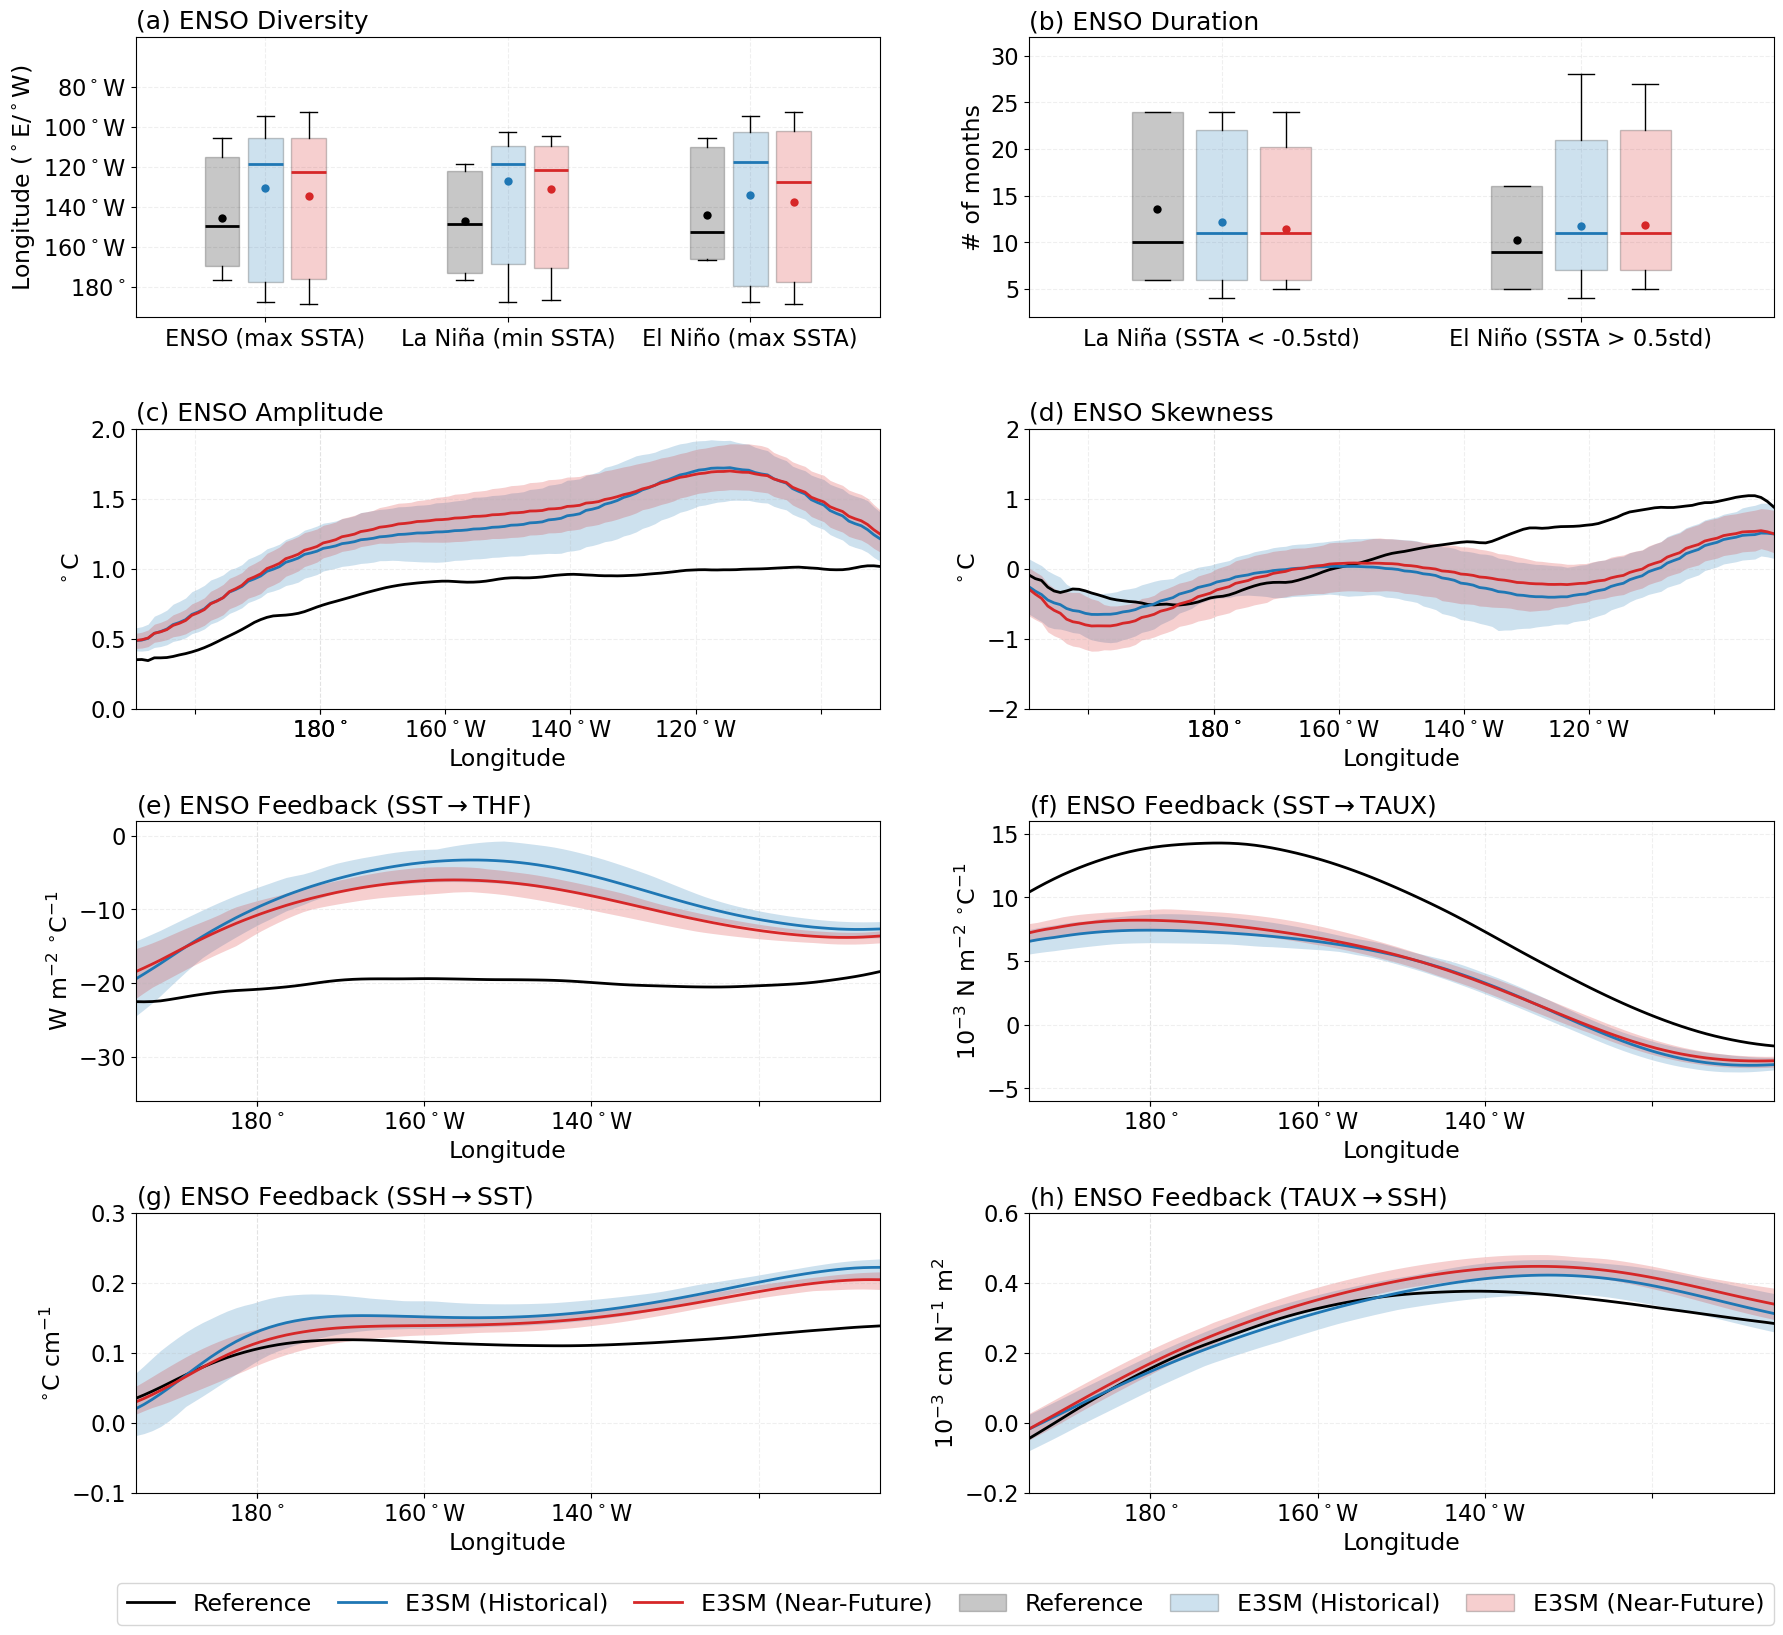

DONE: ./enso_metric_feature_hist_vs_future_erai_v0.pdf


In [6]:
if __name__ == "__main__":
    TOP_DIR   = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_le_paper"
    DATA_DIR  = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le"
    OUT_DIR   = f"{TOP_DIR}/figure_data"   # figure-data cache (NetCDF per metric)
    FIG_DIR   = "./"                       # figure output
    os.makedirs(OUT_DIR, exist_ok=True)
    os.makedirs(FIG_DIR, exist_ok=True)

    MODEL   = "v3.LR.historical"
    groups  = ["hist", "future"]                 # model periods (driver groups)
    PERIOD  = [(1985, 2014), (2015, 2049)]
    NENS    = [25, 25]
    case_id = "v20251015"

    members = None
    verbose = False

    # caching controls
    refresh_all     = True          # True: rebuild all figdata
    refresh_missing = True           # True: only build missing figdata
    diag_print      = True           # True: prints sample sizes + saved var shapes
    pool_members_to_samples = False  # usually False for lon-panels; box-panels always pooled safely

    # plotting defaults
    obs_key = "reference"
    plot_dict = {
        "reference": {"label": "Reference",          "color": "black",     "alpha": 0.22},
        "hist":      {"label": "E3SM (Historical)",  "color": "tab:blue",  "alpha": 0.22},
        "future":    {"label": "E3SM (Near-Future)", "color": "tab:red",   "alpha": 0.22},
    }

    out_name        = "enso_metric_feature_hist_vs_future_erai_v0.pdf"
    fig_format      = "pdf"
    fig_dpi         = 300
    fontz           = 18
    figshape        = (4, 2)         # 4 rows x 2 cols -> 8 panels
    figsize         = (18, 16)
    fig_idx_start   = 0              # 0 -> (a); 4 -> (e)
    lon_int_default = 20.0
    hspace = 0.40
    wspace = 0.20
    
    # lon-panel defaults (consistent with revised class)
    lon_label_latex = True
    lon_spread_mode = "p05p95"       # "p05p95" or "std"

    # -----------------------
    # Reader
    # -----------------------
    reader = ENSODiagReader(
        data_dir=DATA_DIR,
        model=MODEL,
        groups=groups,
        period_list=PERIOD,
        nens=NENS,
        members=members,
        verbose=verbose,
    )

    # -----------------------
    # Targets (8 panels total) -- NO M()
    # Each metric dict is explicit and can use different obs.
    # -----------------------
    metrics_ordered = OrderedDict([
        ("enso_sst_diversity_mode2", {
            "group": "ENSO_perf",
            "obs": {"hist": "ERA-Interim", "future": "ERA-Interim2"},
            "rtol": 1e-2,
            "vars": ["Enso_lon_pos_maxSSTA", "Nina_lon_pos_minSSTA", "Nino_lon_pos_maxSSTA"],
            "vmap": {
                "Enso_lon_pos_maxSSTA": "ENSO (max SSTA)",
                "Nina_lon_pos_minSSTA": "La Niña (min SSTA)",
                "Nino_lon_pos_maxSSTA": "El Niño (max SSTA)",
            },
            "label": "ENSO Diversity",
            "unit": r"Longitude ($^\circ$E/$^\circ$W)",
            "ymin": 165, "ymax": 305,
            "format_lon": True,
        }),

        ("enso_duration", {
            "group": "ENSO_perf",
            "obs": {"hist": "ERA-Interim", "future": "ERA-Interim2"},
            "rtol": 1e-2,
            "vars": ["Nina_duration", "Nino_duration"],
            "vmap": {
                "Nina_duration": "La Niña (SSTA < -0.5std)",
                "Nino_duration": "El Niño (SSTA > 0.5std)",
            },
            "label": "ENSO Duration",
            "unit": r"# of months",
            "ymin": 2, "ymax": 32,
            "format_lon": False,
        }),

        ("enso_amplitude", {
            "group": "ENSO_perf",
            "obs": {"hist": "ERA-Interim", "future": "ERA-Interim2"},  # change per-metric if needed
            "rtol": 1e-2,
            "vars": ["sstStd_lon"],
            "label": "ENSO Amplitude",
            "unit": r"$^\circ$C",
            "ymin": 0.0, "ymax": 2.0,
        }),

        ("enso_sst_skewness", {
            "group": "ENSO_perf",
            "obs": {"hist": "ERA-Interim", "future": "ERA-Interim2"},  # change per-metric if needed
            "rtol": 1e-2,
            "vars": ["sstSke_lon"],
            "label": "ENSO Skewness",
            "unit": r"$^\circ$C",
            "ymin": -2.0, "ymax": 2.0,
        }),

        ("enso_fb_sst_thf", {
            "group": "ENSO_proc",
            "obs": {"hist": "ERA-Interim_ERA-Interim", "future": "ERA-Interim2_ERA-Interim2"},
            "rtol": 1e-1,
            "vars": ["reg_thf_over_sst_lon"],
            "label": r"ENSO Feedback (SST$\rightarrow$THF)",
            "unit": r"W m$^{-2}$ $^{\circ}$C$^{-1}$",
            "ymin": -36, "ymax": 2,
        }),

        ("enso_fb_sst_taux", {
            "group": "ENSO_proc",
            "obs": {"hist": "ERA-Interim_ERA-Interim", "future": "ERA-Interim2_ERA-Interim2"},
            "rtol": 1e-1,
            "vars": ["reg_taux_over_sst_lon"],
            "label": r"ENSO Feedback (SST$\rightarrow$TAUX)",
            "unit": r"10$^{-3}$ N m$^{-2}$ $^{\circ}$C$^{-1}$",
            "ymin": -6, "ymax": 16,
        }),

        ("enso_fb_ssh_sst", {
            "group": "ENSO_proc",
            "obs": {"hist": "ERA-Interim_AVISO", "future": "ERA-Interim2_AVISO2"},
            "rtol": 1e-2,  # override tighter tolerance
            "vars": ["reg_sst_over_ssh_lon"],
            "label": r"ENSO Feedback (SSH$\rightarrow$SST)",
            "unit": r"$^{\circ}$C cm$^{-1}$",
            "ymin": -0.1, "ymax": 0.30,
        }),

        ("enso_fb_taux_ssh", {
            "group": "ENSO_proc",
            "obs": {"hist": "ERA-Interim_AVISO", "future": "ERA-Interim2_AVISO2"},
            "rtol": 1e-2,  # override tighter tolerance
            "vars": ["reg_ssh_over_taux_lon"],
            "label": r"ENSO Feedback (TAUX$\rightarrow$SSH)",
            "unit": r"10$^{-3}$ cm N$^{-1}$ m$^{2}$",
            "ymin": -0.2, "ymax": 0.60,
        }),
    ])

    target_metric_dict = dict(metrics_ordered)
    panel_order = list(metrics_ordered.keys())
    
    # -----------------------
    # Driver (one-call)
    # -----------------------
    driver = ENSOMultiPanelDriver(
        reader=reader,
        out_dir=OUT_DIR,
        fig_dir=FIG_DIR,
        groups=groups,
        obs_key=obs_key,
        plot_dict=plot_dict,
        lon_label_latex=lon_label_latex,
        lon_spread_mode=lon_spread_mode,
    )

    out_path = driver.make_figure(
        target_metric_dict=target_metric_dict,
        panel_order=panel_order,
        case_id=case_id,
        out_name=out_name,
        figshape=figshape,
        figsize=figsize,
        fig_dpi=fig_dpi,
        fig_format=fig_format,
        fontz=fontz,
        fig_idx_start=fig_idx_start,
        lon_int_default=lon_int_default,
        pool_members_to_samples=pool_members_to_samples,
        refresh=refresh_all,
        refresh_missing=refresh_missing,
        diag_print=diag_print,
        hspace = hspace,
        wspace = wspace
    )

    print("DONE:", out_path)

processing period: hist
/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/hist/v3.LR.historical_0051/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_perf/*v20260216*_EnsoSstDiversity_2.nc
/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/hist/v3.LR.historical_0091/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_perf/*v20260216*_EnsoSstDiversity_2.nc
/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/hist/v3.LR.historical_0101/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_perf/*v20260216*_EnsoSstDiversity_2.nc
/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/hist/v3.LR.historical_0111/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_perf/*v20260216*_EnsoSstDiversity_2.nc
/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/hist/v3.LR.historical_0121/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_perf/*v20260216*_EnsoSstDiversity_2.nc
/lcrc/group/e3sm

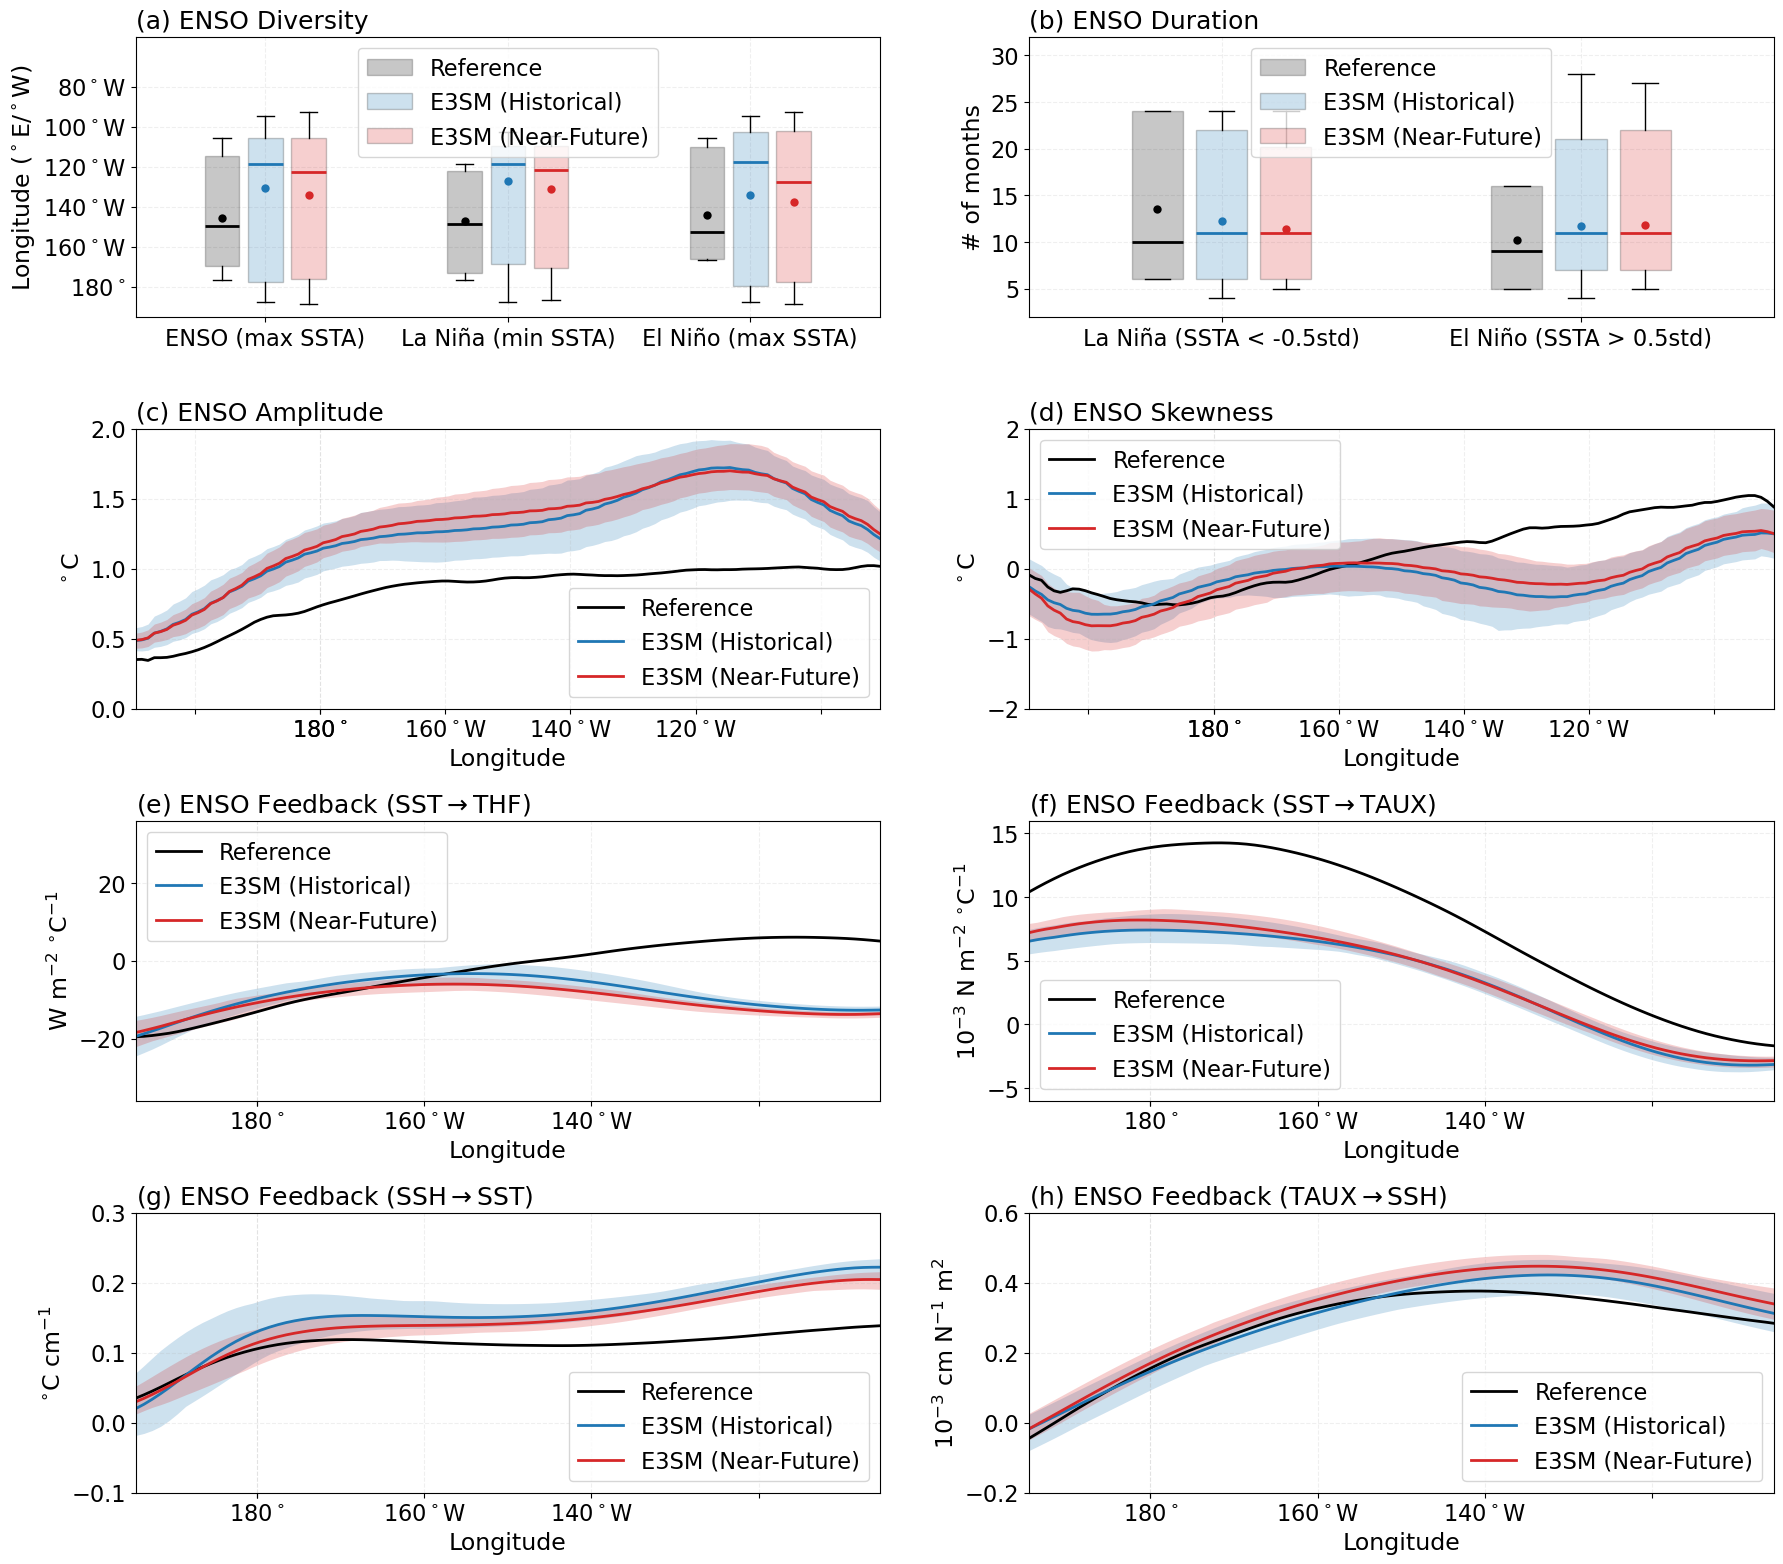

DONE: ./enso_metric_feature_hist_vs_future_erai.pdf


In [6]:
if __name__ == "__main__":
    TOP_DIR   = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_le_paper"
    DATA_DIR  = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le"
    OUT_DIR   = f"{TOP_DIR}/figure_data"   # figure-data cache (NetCDF per metric)
    FIG_DIR   = "./"                       # figure output
    os.makedirs(OUT_DIR, exist_ok=True)
    os.makedirs(FIG_DIR, exist_ok=True)

    MODEL   = "v3.LR.historical"
    groups  = ["hist", "future"]                 # model periods (driver groups)
    PERIOD  = [(1985, 2014), (2015, 2049)]
    NENS    = [25, 25]
    case_id = "v20260216"

    members = None
    verbose = False

    # caching controls
    refresh_all     = True          # True: rebuild all figdata
    refresh_missing = True           # True: only build missing figdata
    diag_print      = True           # True: prints sample sizes + saved var shapes
    pool_members_to_samples = False  # usually False for lon-panels; box-panels always pooled safely

    # plotting defaults
    obs_key = "reference"
    plot_dict = {
        "reference": {"label": "Reference",          "color": "black",     "alpha": 0.22},
        "hist":      {"label": "E3SM (Historical)",  "color": "tab:blue",  "alpha": 0.22},
        "future":    {"label": "E3SM (Near-Future)", "color": "tab:red",   "alpha": 0.22},
    }

    out_name        = "enso_metric_feature_hist_vs_future_erai.pdf"
    fig_format      = "pdf"
    fig_dpi         = 300
    fontz           = 18
    figshape        = (4, 2)         # 4 rows x 2 cols -> 8 panels
    figsize         = (18, 16)
    fig_idx_start   = 0              # 0 -> (a); 4 -> (e)
    lon_int_default = 20.0
    hspace = 0.40
    wspace = 0.20
    
    # lon-panel defaults (consistent with revised class)
    lon_label_latex = True
    lon_spread_mode = "p05p95"       # "p05p95" or "std"

    # -----------------------
    # Reader
    # -----------------------
    reader = ENSODiagReader(
        data_dir=DATA_DIR,
        model=MODEL,
        groups=groups,
        period_list=PERIOD,
        nens=NENS,
        members=members,
        verbose=verbose,
    )

    # -----------------------
    # Targets (8 panels total) -- NO M()
    # Each metric dict is explicit and can use different obs.
    # -----------------------
    metrics_ordered = OrderedDict([
        ("enso_sst_diversity_mode2", {
            "group": "ENSO_perf",
            "obs": {"hist": "ERA-Interim", "future": "FAKE-FUTURE1"},
            "rtol": 1e-2,
            "vars": ["Enso_lon_pos_maxSSTA", "Nina_lon_pos_minSSTA", "Nino_lon_pos_maxSSTA"],
            "vmap": {
                "Enso_lon_pos_maxSSTA": "ENSO (max SSTA)",
                "Nina_lon_pos_minSSTA": "La Niña (min SSTA)",
                "Nino_lon_pos_maxSSTA": "El Niño (max SSTA)",
            },
            "label": "ENSO Diversity",
            "unit": r"Longitude ($^\circ$E/$^\circ$W)",
            "ymin": 165, "ymax": 305,
            "format_lon": True,
        }),

        ("enso_duration", {
            "group": "ENSO_perf",
            "obs": {"hist": "ERA-Interim", "future": "FAKE-FUTURE1"},
            "rtol": 1e-2,
            "vars": ["Nina_duration", "Nino_duration"],
            "vmap": {
                "Nina_duration": "La Niña (SSTA < -0.5std)",
                "Nino_duration": "El Niño (SSTA > 0.5std)",
            },
            "label": "ENSO Duration",
            "unit": r"# of months",
            "ymin": 2, "ymax": 32,
            "format_lon": False,
        }),

        ("enso_amplitude", {
            "group": "ENSO_perf",
            "obs": {"hist": "ERA-Interim", "future": "FAKE-FUTURE1"},  # change per-metric if needed
            "rtol": 1e-2,
            "vars": ["sstStd_lon"],
            "label": "ENSO Amplitude",
            "unit": r"$^\circ$C",
            "ymin": 0.0, "ymax": 2.0,
        }),

        ("enso_sst_skewness", {
            "group": "ENSO_perf",
            "obs": {"hist": "ERA-Interim", "future": "FAKE-FUTURE1"},  # change per-metric if needed
            "rtol": 1e-2,
            "vars": ["sstSke_lon"],
            "label": "ENSO Skewness",
            "unit": r"$^\circ$C",
            "ymin": -2.0, "ymax": 2.0,
        }),

        ("enso_fb_sst_thf", {
            "group": "ENSO_proc",
            "obs": {"hist": "ERA-Interim_ERA-Interim", "future": "FAKE-FUTURE1_FAKE-FUTURE1"},
            "rtol": 1e-1,
            "vars": ["reg_thf_over_sst_lon"],
            "label": r"ENSO Feedback (SST$\rightarrow$THF)",
            "unit": r"W m$^{-2}$ $^{\circ}$C$^{-1}$",
            "ymin": -36, "ymax": 36,
        }),

        ("enso_fb_sst_taux", {
            "group": "ENSO_proc",
            "obs": {"hist": "ERA-Interim_ERA-Interim", "future": "FAKE-FUTURE1_FAKE-FUTURE1"},
            "rtol": 1e-1,
            "vars": ["reg_taux_over_sst_lon"],
            "label": r"ENSO Feedback (SST$\rightarrow$TAUX)",
            "unit": r"10$^{-3}$ N m$^{-2}$ $^{\circ}$C$^{-1}$",
            "ymin": -6, "ymax": 16,
        }),

        ("enso_fb_ssh_sst", {
            "group": "ENSO_proc",
            "obs": {"hist": "ERA-Interim_ERA-Interim", "future": "FAKE-FUTURE1_FAKE-FUTURE1"},
            "rtol": 1e-2,  # override tighter tolerance
            "vars": ["reg_sst_over_ssh_lon"],
            "label": r"ENSO Feedback (SSH$\rightarrow$SST)",
            "unit": r"$^{\circ}$C cm$^{-1}$",
            "ymin": -0.1, "ymax": 0.30,
        }),

        ("enso_fb_taux_ssh", {
            "group": "ENSO_proc",
            "obs": {"hist": "ERA-Interim_ERA-Interim", "future": "FAKE-FUTURE1_FAKE-FUTURE1"},
            "rtol": 1e-2,  # override tighter tolerance
            "vars": ["reg_ssh_over_taux_lon"],
            "label": r"ENSO Feedback (TAUX$\rightarrow$SSH)",
            "unit": r"10$^{-3}$ cm N$^{-1}$ m$^{2}$",
            "ymin": -0.2, "ymax": 0.60,
        }),
    ])

    target_metric_dict = dict(metrics_ordered)
    panel_order = list(metrics_ordered.keys())
    
    # -----------------------
    # Driver (one-call)
    # -----------------------
    driver = ENSOMultiPanelDriver(
        reader=reader,
        out_dir=OUT_DIR,
        fig_dir=FIG_DIR,
        groups=groups,
        obs_key=obs_key,
        plot_dict=plot_dict,
        lon_label_latex=lon_label_latex,
        lon_spread_mode=lon_spread_mode,
    )

    out_path = driver.make_figure(
        target_metric_dict=target_metric_dict,
        panel_order=panel_order,
        case_id=case_id,
        out_name=out_name,
        figshape=figshape,
        figsize=figsize,
        fig_dpi=fig_dpi,
        fig_format=fig_format,
        fontz=fontz,
        fig_idx_start=fig_idx_start,
        lon_int_default=lon_int_default,
        pool_members_to_samples=pool_members_to_samples,
        refresh=refresh_all,
        refresh_missing=refresh_missing,
        diag_print=diag_print,
        hspace = hspace,
        wspace = wspace
    )

    print("DONE:", out_path)

processing period: hist
/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/hist/v3.LR.historical_0051/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_perf/*v20260212*_EnsoSstDiversity_2.nc
/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/hist/v3.LR.historical_0091/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_perf/*v20260212*_EnsoSstDiversity_2.nc
/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/hist/v3.LR.historical_0101/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_perf/*v20260212*_EnsoSstDiversity_2.nc
/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/hist/v3.LR.historical_0111/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_perf/*v20260212*_EnsoSstDiversity_2.nc
/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le/hist/v3.LR.historical_0121/pcmdi_diags/model_vs_obs/metrics_data/enso_metric/ENSO_perf/*v20260212*_EnsoSstDiversity_2.nc
/lcrc/group/e3sm

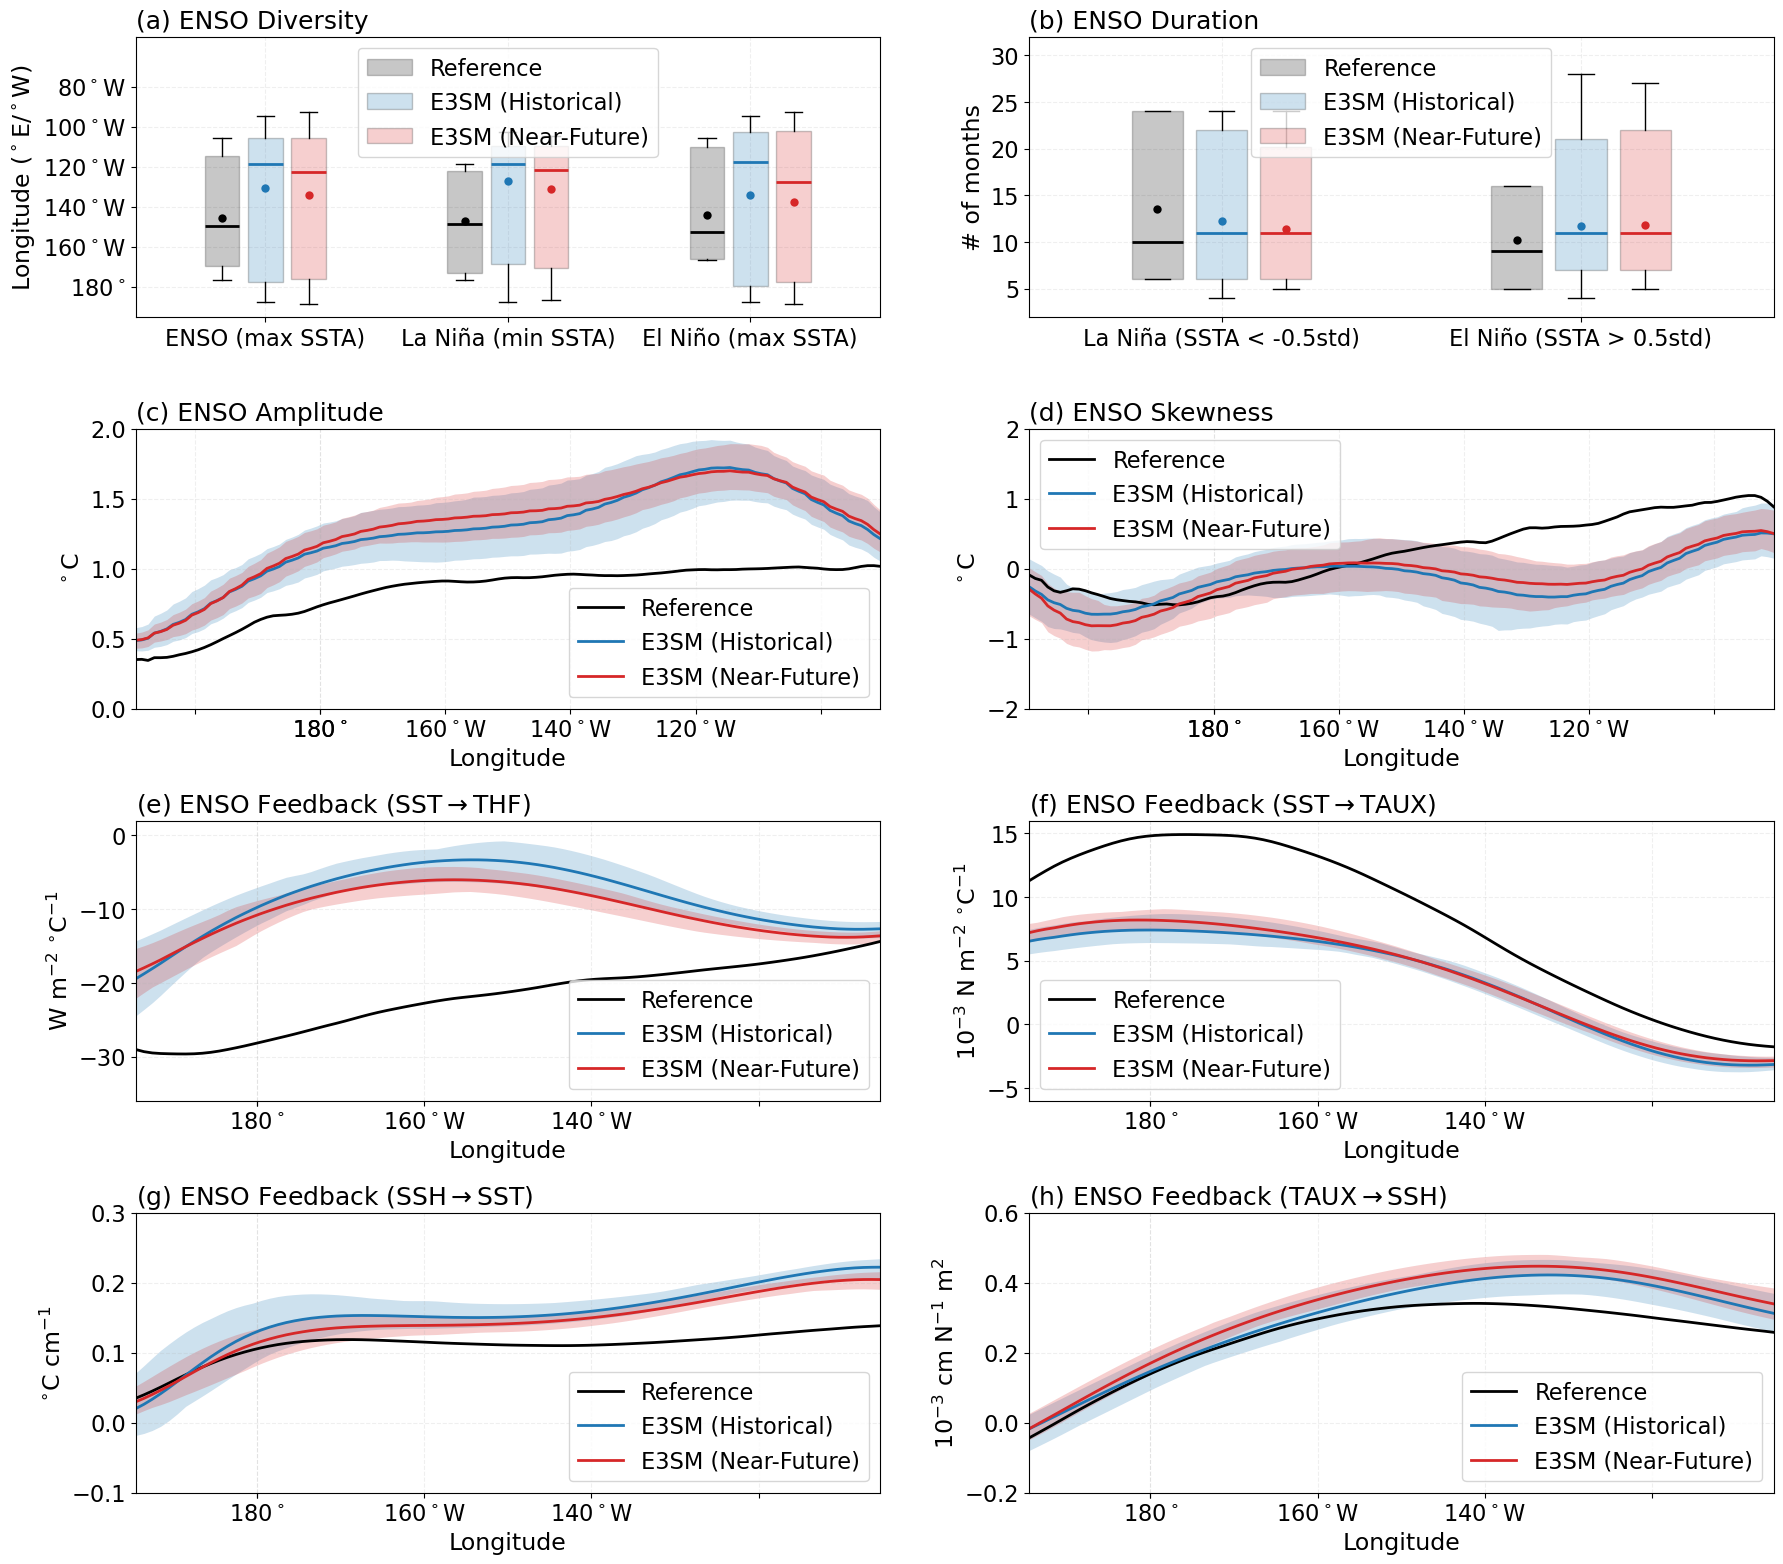

DONE: ./enso_metric_feature_hist_vs_future.pdf


In [7]:
if __name__ == "__main__":
    TOP_DIR   = "/lcrc/group/e3sm/ac.szhang/acme_scratch/e3sm_project/v3_le_paper"
    DATA_DIR  = "/lcrc/group/e3sm/public_html/diagnostic_output/ac.szhang/e3sm-pcmdi-le"
    OUT_DIR   = f"{TOP_DIR}/figure_data"   # figure-data cache (NetCDF per metric)
    FIG_DIR   = "./"                       # figure output
    os.makedirs(OUT_DIR, exist_ok=True)
    os.makedirs(FIG_DIR, exist_ok=True)

    MODEL   = "v3.LR.historical"
    groups  = ["hist", "future"]                 # model periods (driver groups)
    PERIOD  = [(1985, 2014), (2015, 2049)]
    NENS    = [25, 25]
    case_id = "v20260212"

    members = None
    verbose = False

    # caching controls
    refresh_all     = True          # True: rebuild all figdata
    refresh_missing = True           # True: only build missing figdata
    diag_print      = True           # True: prints sample sizes + saved var shapes
    pool_members_to_samples = False  # usually False for lon-panels; box-panels always pooled safely

    # plotting defaults
    obs_key = "reference"
    plot_dict = {
        "reference": {"label": "Reference",          "color": "black",     "alpha": 0.22},
        "hist":      {"label": "E3SM (Historical)",  "color": "tab:blue",  "alpha": 0.22},
        "future":    {"label": "E3SM (Near-Future)", "color": "tab:red",   "alpha": 0.22},
    }

    out_name        = "enso_metric_feature_hist_vs_future.pdf"
    fig_format      = "pdf"
    fig_dpi         = 300
    fontz           = 18
    figshape        = (4, 2)         # 4 rows x 2 cols -> 8 panels
    figsize         = (18, 16)
    fig_idx_start   = 0              # 0 -> (a); 4 -> (e)
    lon_int_default = 20.0
    hspace = 0.40
    wspace = 0.20
    
    # lon-panel defaults (consistent with revised class)
    lon_label_latex = True
    lon_spread_mode = "p05p95"       # "p05p95" or "std"

    # -----------------------
    # Reader
    # -----------------------
    reader = ENSODiagReader(
        data_dir=DATA_DIR,
        model=MODEL,
        groups=groups,
        period_list=PERIOD,
        nens=NENS,
        members=members,
        verbose=verbose,
    )

    # -----------------------
    # Targets (8 panels total) -- NO M()
    # Each metric dict is explicit and can use different obs.
    # -----------------------
    metrics_ordered = OrderedDict([
        ("enso_sst_diversity_mode2", {
            "group": "ENSO_perf",
            "obs": {"hist": "ERA-Interim", "future": "FAKE-FUTURE1"},
            "rtol": 1e-2,
            "vars": ["Enso_lon_pos_maxSSTA", "Nina_lon_pos_minSSTA", "Nino_lon_pos_maxSSTA"],
            "vmap": {
                "Enso_lon_pos_maxSSTA": "ENSO (max SSTA)",
                "Nina_lon_pos_minSSTA": "La Niña (min SSTA)",
                "Nino_lon_pos_maxSSTA": "El Niño (max SSTA)",
            },
            "label": "ENSO Diversity",
            "unit": r"Longitude ($^\circ$E/$^\circ$W)",
            "ymin": 165, "ymax": 305,
            "format_lon": True,
        }),

        ("enso_duration", {
            "group": "ENSO_perf",
            "obs": {"hist": "ERA-Interim", "future": "FAKE-FUTURE1"},
            "rtol": 1e-2,
            "vars": ["Nina_duration", "Nino_duration"],
            "vmap": {
                "Nina_duration": "La Niña (SSTA < -0.5std)",
                "Nino_duration": "El Niño (SSTA > 0.5std)",
            },
            "label": "ENSO Duration",
            "unit": r"# of months",
            "ymin": 2, "ymax": 32,
            "format_lon": False,
        }),

        ("enso_amplitude", {
            "group": "ENSO_perf",
            "obs": {"hist": "ERA-Interim", "future": "FAKE-FUTURE1"},  # change per-metric if needed
            "rtol": 1e-2,
            "vars": ["sstStd_lon"],
            "label": "ENSO Amplitude",
            "unit": r"$^\circ$C",
            "ymin": 0.0, "ymax": 2.0,
        }),

        ("enso_sst_skewness", {
            "group": "ENSO_perf",
            "obs": {"hist": "ERA-Interim", "future": "FAKE-FUTURE1"},  # change per-metric if needed
            "rtol": 1e-2,
            "vars": ["sstSke_lon"],
            "label": "ENSO Skewness",
            "unit": r"$^\circ$C",
            "ymin": -2.0, "ymax": 2.0,
        }),

        ("enso_fb_sst_thf", {
            "group": "ENSO_proc",
            "obs": {"hist": "ERA-Interim_Tropflux", "future": "FAKE-FUTURE1_FAKE-FUTURE2"},
            "rtol": 1e-1,
            "vars": ["reg_thf_over_sst_lon"],
            "label": r"ENSO Feedback (SST$\rightarrow$THF)",
            "unit": r"W m$^{-2}$ $^{\circ}$C$^{-1}$",
            "ymin": -36, "ymax": 2,
        }),

        ("enso_fb_sst_taux", {
            "group": "ENSO_proc",
            "obs": {"hist": "ERA-Interim_Tropflux", "future": "FAKE-FUTURE1_FAKE-FUTURE2"},
            "rtol": 1e-1,
            "vars": ["reg_taux_over_sst_lon"],
            "label": r"ENSO Feedback (SST$\rightarrow$TAUX)",
            "unit": r"10$^{-3}$ N m$^{-2}$ $^{\circ}$C$^{-1}$",
            "ymin": -6, "ymax": 16,
        }),

        ("enso_fb_ssh_sst", {
            "group": "ENSO_proc",
            "obs": {"hist": "ERA-Interim_Tropflux", "future": "FAKE-FUTURE1_FAKE-FUTURE2"},
            "rtol": 1e-2,  # override tighter tolerance
            "vars": ["reg_sst_over_ssh_lon"],
            "label": r"ENSO Feedback (SSH$\rightarrow$SST)",
            "unit": r"$^{\circ}$C cm$^{-1}$",
            "ymin": -0.1, "ymax": 0.30,
        }),

        ("enso_fb_taux_ssh", {
            "group": "ENSO_proc",
            "obs": {"hist": "Tropflux_Tropflux", "future": "FAKE-FUTURE2_FAKE-FUTURE2"},
            "rtol": 1e-2,  # override tighter tolerance
            "vars": ["reg_ssh_over_taux_lon"],
            "label": r"ENSO Feedback (TAUX$\rightarrow$SSH)",
            "unit": r"10$^{-3}$ cm N$^{-1}$ m$^{2}$",
            "ymin": -0.2, "ymax": 0.60,
        }),
    ])

    target_metric_dict = dict(metrics_ordered)
    panel_order = list(metrics_ordered.keys())
    
    # -----------------------
    # Driver (one-call)
    # -----------------------
    driver = ENSOMultiPanelDriver(
        reader=reader,
        out_dir=OUT_DIR,
        fig_dir=FIG_DIR,
        groups=groups,
        obs_key=obs_key,
        plot_dict=plot_dict,
        lon_label_latex=lon_label_latex,
        lon_spread_mode=lon_spread_mode,
    )

    out_path = driver.make_figure(
        target_metric_dict=target_metric_dict,
        panel_order=panel_order,
        case_id=case_id,
        out_name=out_name,
        figshape=figshape,
        figsize=figsize,
        fig_dpi=fig_dpi,
        fig_format=fig_format,
        fontz=fontz,
        fig_idx_start=fig_idx_start,
        lon_int_default=lon_int_default,
        pool_members_to_samples=pool_members_to_samples,
        refresh=refresh_all,
        refresh_missing=refresh_missing,
        diag_print=diag_print,
        hspace = hspace,
        wspace = wspace
    )

    print("DONE:", out_path)